In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv


#######

In [2]:
###########

**READING ALL THE FILES IN TO A DATAFRAME**

In [3]:
import pandas as pd
import numpy as np

In [4]:
booknow_booking = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv')

In [5]:
booknow_booking.head()

,book_theater_id,show_datetime,booking_datetime,tickets_booked
0,book_00244,2023-01-01 19:00:00,2023-01-01 16:00:00,1
1,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,3
2,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,6
3,book_00244,2023-01-01 20:00:00,2023-01-01 16:00:00,2
4,book_00151,2023-01-01 20:00:00,2023-01-01 01:00:00,5


In [6]:
booknow_theaters = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv')

In [7]:
booknow_theaters.head()

,book_theater_id,theater_type,theater_area,latitude,longitude
0,book_00093,Drama,Area_001,22.619233,78.113017
1,book_00078,Drama,Area_001,22.619233,78.113017
2,book_00291,Drama,Area_001,22.619233,78.113017
3,book_00258,Drama,Area_001,22.619233,78.113017
4,book_00212,Drama,Area_002,23.004410,79.934515


In [8]:
booknow_visits = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv')

In [9]:
booknow_visits.head()

,book_theater_id,show_date,audience_count
0,book_00001,2023-01-13,50
1,book_00001,2023-01-14,64
2,book_00001,2023-01-15,58
3,book_00001,2023-01-16,44
4,book_00001,2023-01-18,12


In [10]:
cinePOS_booking = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv')

In [11]:
cinePOS_booking.head()

,cine_theater_id,show_datetime,booking_datetime,tickets_sold
0,cinePOS_00001,2023-01-01 11:00:00,2023-01-01 09:00:00,1
1,cinePOS_00002,2023-01-01 13:00:00,2023-01-01 06:00:00,3
2,cinePOS_00003,2023-01-01 16:00:00,2023-01-01 14:00:00,2
3,cinePOS_00004,2023-01-01 17:00:00,2023-01-01 11:00:00,5
4,cinePOS_00005,2023-01-01 17:00:00,2023-01-01 03:00:00,13


In [12]:
cinePOS_theaters = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv')

In [13]:
cinePOS_theaters.head()

,cine_theater_id,theater_type,theater_area,latitude,longitude
0,cinePOS_05466,Other,Area_104,22.619233,78.113017
1,cinePOS_08708,Other,Area_104,22.619233,78.113017
2,cinePOS_00753,Other,Area_104,22.619233,78.113017
3,cinePOS_05776,Other,Area_104,22.619233,78.113017
4,cinePOS_07536,Other,Area_104,23.004410,79.934515


In [14]:
date_info = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv')

In [15]:
date_info.head()

,show_date,day_of_week
0,2023-01-01,Sunday
1,2023-01-02,Monday
2,2023-01-03,Tuesday
3,2023-01-04,Wednesday
4,2023-01-05,Thursday


In [16]:
movie_theater_id_relation = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv')

In [17]:
movie_theater_id_relation.head()

,book_theater_id,cine_theater_id
0,book_00509,cinePOS_01261
1,book_00063,cinePOS_02467
2,book_00054,cinePOS_08923
3,book_00094,cinePOS_02479
4,book_00052,cinePOS_06750


In [18]:
sample_submission = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv')

In [19]:
sample_submission.head()

,ID,audience_count
0,book_00001_2024-03-01,0
1,book_00001_2024-03-02,0
2,book_00001_2024-03-03,0
3,book_00001_2024-03-04,0
4,book_00001_2024-03-06,0


*BOOKNOW_BOOKING - EDA*

In [20]:
booknow_booking.shape

(68336, 4)

In [21]:
booknow_booking.isnull().sum()

book_theater_id     0
show_datetime       0
booking_datetime    0
tickets_booked      0
dtype: int64

There is no null values in booknow_booking


In [22]:
booknow_booking['tickets_booked'].value_counts()

tickets_booked
2     28595
3     11235
4      9139
5      4271
6      3498
      ...  
95        1
74        1
72        1
69        1
70        1
Name: count, Length: 66, dtype: int64

In [23]:
booknow_booking['tickets_booked'].nunique()

66

There are 66 values in tickets_booked column

In [24]:
booknow_booking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68336 entries, 0 to 68335
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   book_theater_id   68336 non-null  object
 1   show_datetime     68336 non-null  object
 2   booking_datetime  68336 non-null  object
 3   tickets_booked    68336 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 2.1+ MB


ticket_booked column is the only integer type column in booknow_booking dataset


In [25]:
booknow_booking['tickets_booked'].describe()

count    68336.000000
mean         4.425808
std          4.808945
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max        100.000000
Name: tickets_booked, dtype: float64

In [26]:

booknow_booking['tickets_booked'].skew()



4.815808645884737

In [27]:
booknow_booking['tickets_booked'].kurt()

37.12766412576657

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='tickets_booked', ylabel='Count'>

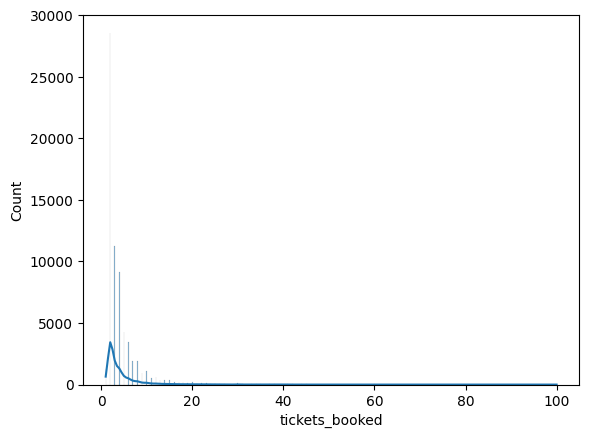

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(booknow_booking['tickets_booked'], kde=True)   # histogram , density
           


<Axes: xlabel='tickets_booked'>

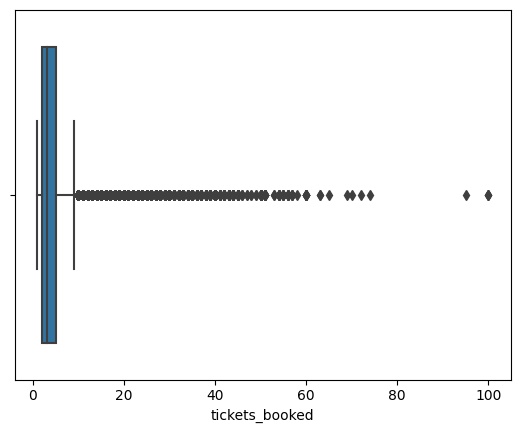

In [29]:



sns.boxplot(x=booknow_booking['tickets_booked'])            # boxplot for outliers


In [30]:
#outlier detection
Q1 = booknow_booking['tickets_booked'].quantile(0.25)
Q3 = booknow_booking['tickets_booked'].quantile(0.75)
IQR = Q3 - Q1
outliers = booknow_booking[(booknow_booking['tickets_booked'] < Q1 - 1.5*IQR) | (booknow_booking['tickets_booked'] > Q3 + 1.5*IQR)]


In [31]:
IQR

3.0

In [32]:
outliers

,book_theater_id,show_datetime,booking_datetime,tickets_booked
15,book_00099,2023-01-02 17:00:00,2023-01-02 17:00:00,41
16,book_00099,2023-01-02 17:00:00,2023-01-02 17:00:00,13
53,book_00031,2023-01-04 18:00:00,2023-01-04 14:00:00,10
62,book_00374,2023-01-04 19:00:00,2023-01-04 18:00:00,22
68,book_00309,2023-01-04 22:00:00,2023-01-04 22:00:00,10
...,...,...,...,...
68306,book_00307,2024-02-28 21:00:00,2024-02-16 18:00:00,13
68315,book_00207,2024-02-28 21:00:00,2024-02-22 15:00:00,32
68316,book_00071,2024-02-28 21:00:00,2024-02-26 16:00:00,10
68317,book_00358,2024-02-28 21:00:00,2024-02-20 22:00:00,19


*1.inference from histogram - majority of bookings are concentrated on low values like 1,2,3
2 The distribution is heavily right-skewed , tail towards hight values indicating most customers book only few tickets only in rare cases they book a very large number of tickets***

*inference from boxplot - Median no of tickets is close to 1 or 2, IQR values are small indicates most values are clustered at low end(1 or 2) and outliers on right side (20 to 100)*

*EDA ON BOOKNOW_THEATERS DATASET*

In [33]:
booknow_theaters.head()

,book_theater_id,theater_type,theater_area,latitude,longitude
0,book_00093,Drama,Area_001,22.619233,78.113017
1,book_00078,Drama,Area_001,22.619233,78.113017
2,book_00291,Drama,Area_001,22.619233,78.113017
3,book_00258,Drama,Area_001,22.619233,78.113017
4,book_00212,Drama,Area_002,23.004410,79.934515


In [34]:
booknow_theaters.shape

(829, 5)

In [35]:
booknow_theaters.isnull().sum()

book_theater_id    515
theater_type         0
theater_area         0
latitude             0
longitude            0
dtype: int64

In [36]:
booknow_theaters['theater_type'].value_counts()

theater_type
Other     411
Comedy    196
Drama     183
Action     39
Name: count, dtype: int64

In [37]:
booknow_theaters['theater_type'].nunique()

4

In [38]:
booknow_theaters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829 entries, 0 to 828
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   book_theater_id  314 non-null    object 
 1   theater_type     829 non-null    object 
 2   theater_area     829 non-null    object 
 3   latitude         829 non-null    float64
 4   longitude        829 non-null    float64
dtypes: float64(2), object(3)
memory usage: 32.5+ KB


columns latitude and longitude are numerical, book_theater_id, theater_type, theater_area are categorical

In [39]:
booknow_theaters['book_theater_id'].nunique()

314

In [40]:
booknow_theaters['book_theater_id'].isnull().sum()

515

In [41]:
booknow_theaters['book_theater_id'].shape

(829,)

In [42]:
booknow_theaters['theater_area'].value_counts()

theater_area
Area_003    64
Area_006    58
Area_002    51
Area_010    39
Area_004    30
            ..
Area_067     2
Area_068     2
Area_070     2
Area_071     2
Area_103     2
Name: count, Length: 103, dtype: int64

In [43]:
booknow_theaters['theater_area'].nunique()

103

<Axes: xlabel='theater_area', ylabel='count'>

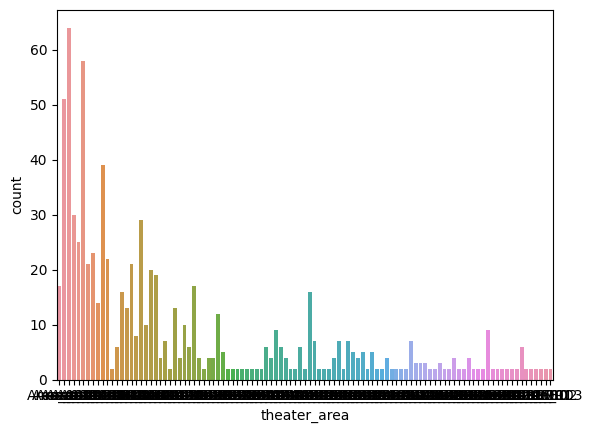

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=booknow_theaters['theater_area'])



theater_area at the start of the columns are high in number means they are popular among people while the end part is not popular 

In [45]:
booknow_theaters['latitude'].shape

(829,)

In [46]:
booknow_theaters['latitude'].max()

26.34943589872136

In [47]:
booknow_theaters['latitude'].min()

22.025970098721352

In [48]:
booknow_theaters['latitude'].describe()

count    829.000000
mean      23.000000
std        0.833863
min       22.025970
25%       22.619233
50%       23.004410
75%       23.018784
max       26.349436
Name: latitude, dtype: float64

In [49]:
booknow_theaters['latitude'].value_counts()

latitude
22.176869    62
23.005894    58
23.004410    51
23.018719    39
23.009443    29
             ..
23.022921     2
23.008899     2
23.689943     2
22.634677     2
23.002470     2
Name: count, Length: 108, dtype: int64

In [50]:
booknow_theaters['latitude'].skew()

2.6579465061888063

In [51]:
booknow_theaters['latitude'].kurt()

7.516293556662079

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='latitude', ylabel='Count'>

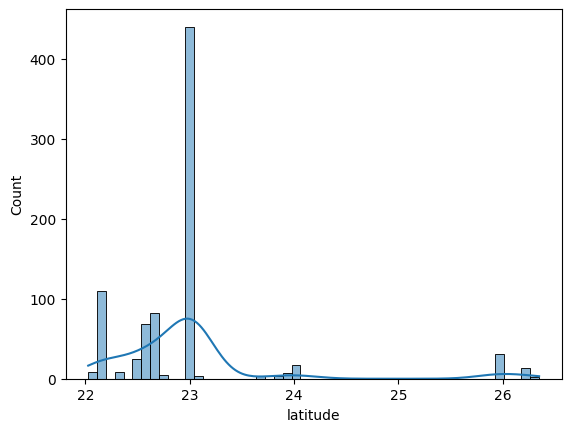

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(booknow_theaters['latitude'], kde=True)

<Axes: xlabel='latitude'>

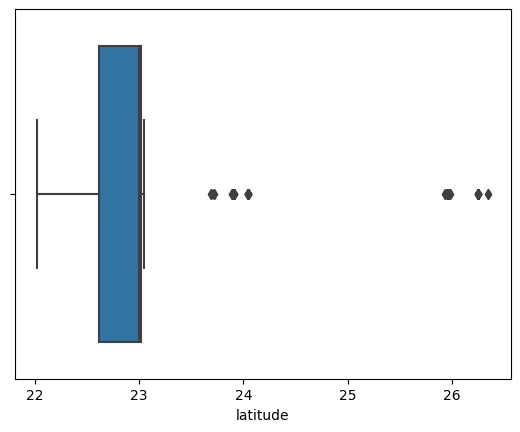

In [53]:
sns.boxplot(x=booknow_theaters['latitude']) 

The majority of theaters are located within latitude 22–23.5, suggesting they are in the same geographic band

In [54]:
booknow_theaters['longitude'].max()

81.74323502016887

In [55]:
booknow_theaters['longitude'].min()

76.11209770016887

In [56]:
booknow_theaters['longitude'].describe()

count    829.000000
mean      79.000000
std        1.460388
min       76.112098
25%       78.170501
50%       79.908065
75%       79.934515
max       81.743235
Name: longitude, dtype: float64

In [57]:
booknow_theaters['longitude'].value_counts()

longitude
76.191001    62
79.915496    58
79.934515    51
79.915295    39
79.942620    29
             ..
79.950447     2
79.916698     2
79.457469     2
78.196426     2
79.918290     2
Name: count, Length: 108, dtype: int64

In [58]:
booknow_theaters['longitude'].skew()

-0.937728675570025

In [59]:
booknow_theaters['longitude'].kurt()

-0.5440643637657954

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='longitude', ylabel='Count'>

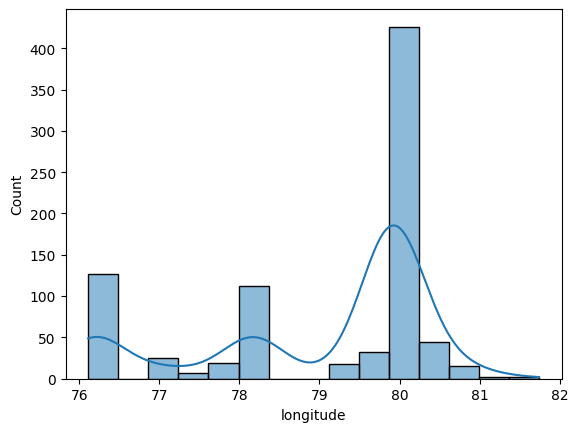

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(booknow_theaters['longitude'], kde=True)

<Axes: xlabel='longitude'>

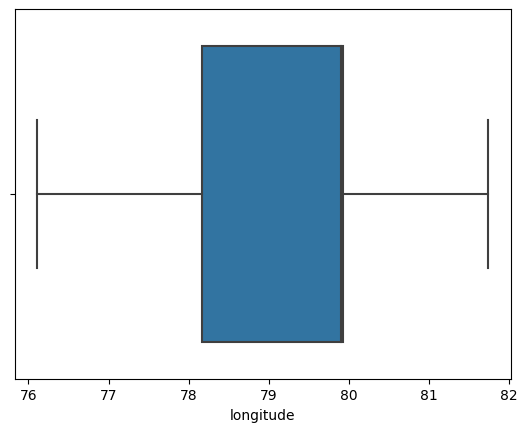

In [61]:
sns.boxplot(x=booknow_theaters['longitude'])

Histogram shows multiple peaks → theaters grouped in specific regions.

Boxplot shows wide spread but no strong outliers.

Strongest concentration is at longitude 80 (main area of theaters).

In [62]:
booknow_theaters[['latitude', 'longitude']].corr()


,latitude,longitude
latitude,1.000000,0.644706
longitude,0.644706,1.000000


*EDA ON BOOKNOW_VISITS*

In [63]:
booknow_visits.head()

,book_theater_id,show_date,audience_count
0,book_00001,2023-01-13,50
1,book_00001,2023-01-14,64
2,book_00001,2023-01-15,58
3,book_00001,2023-01-16,44
4,book_00001,2023-01-18,12


In [64]:
booknow_visits.shape

(214046, 3)

In [65]:
booknow_visits.isnull().sum()

book_theater_id    0
show_date          0
audience_count     0
dtype: int64

In [66]:
booknow_visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214046 entries, 0 to 214045
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   book_theater_id  214046 non-null  object
 1   show_date        214046 non-null  object
 2   audience_count   214046 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 4.9+ MB


In [67]:
booknow_visits['audience_count'].describe()

count    214046.000000
mean         41.616568
std          32.834918
min           2.000000
25%          18.000000
50%          34.000000
75%          58.000000
max        1350.000000
Name: audience_count, dtype: float64

In [68]:
booknow_visits['book_theater_id'].nunique()

826

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='audience_count', ylabel='Count'>

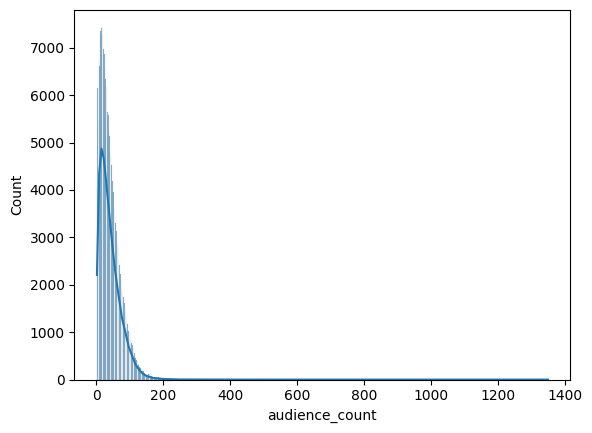

In [69]:
sns.histplot(booknow_visits['audience_count'], kde=True)

distribution is heavily right-skewed with a long tail stretching up to 1400.

This means most shows had small audiences, but a few had very large audiences.

<Axes: xlabel='audience_count'>

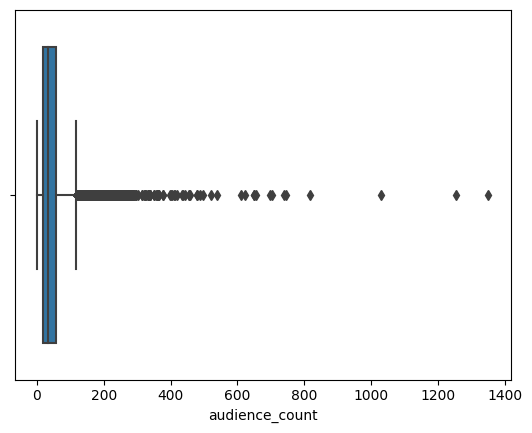

In [70]:
sns.boxplot(x=booknow_visits['audience_count'])

large number of outliers spread across the higher audience counts (200–1400)

*EDA ON CINEPOS_BOOKING*

In [71]:
cinePOS_booking.head()

,cine_theater_id,show_datetime,booking_datetime,tickets_sold
0,cinePOS_00001,2023-01-01 11:00:00,2023-01-01 09:00:00,1
1,cinePOS_00002,2023-01-01 13:00:00,2023-01-01 06:00:00,3
2,cinePOS_00003,2023-01-01 16:00:00,2023-01-01 14:00:00,2
3,cinePOS_00004,2023-01-01 17:00:00,2023-01-01 11:00:00,5
4,cinePOS_00005,2023-01-01 17:00:00,2023-01-01 03:00:00,13


In [72]:
cinePOS_booking.shape

(1641966, 4)

In [73]:
cinePOS_booking.isnull().sum()

cine_theater_id     0
show_datetime       0
booking_datetime    0
tickets_sold        0
dtype: int64

In [74]:
cinePOS_booking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1641966 entries, 0 to 1641965
Data columns (total 4 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   cine_theater_id   1641966 non-null  object
 1   show_datetime     1641966 non-null  object
 2   booking_datetime  1641966 non-null  object
 3   tickets_sold      1641966 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 50.1+ MB


In [75]:
cinePOS_booking['cine_theater_id'].nunique()

13161

In [76]:
cinePOS_booking['cine_theater_id'].value_counts()

cine_theater_id
cinePOS_03019    921
cinePOS_05965    679
cinePOS_10811    669
cinePOS_03773    647
cinePOS_05725    646
                ... 
cinePOS_13133      1
cinePOS_13134      1
cinePOS_13136      1
cinePOS_13137      1
cinePOS_13161      1
Name: count, Length: 13161, dtype: int64

In [77]:
cinePOS_booking['tickets_sold'].describe()

count    1.641966e+06
mean     4.987345e+00
std      5.234901e+00
min      1.000000e+00
25%      2.000000e+00
50%      3.000000e+00
75%      6.000000e+00
max      1.000000e+02
Name: tickets_sold, dtype: float64

In [78]:
cinePOS_booking['tickets_sold'].max()

100

In [79]:
cinePOS_booking['tickets_sold'].min()

1

In [80]:
cinePOS_booking['tickets_sold'].mean()

4.987345048557644

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='tickets_sold', ylabel='Count'>

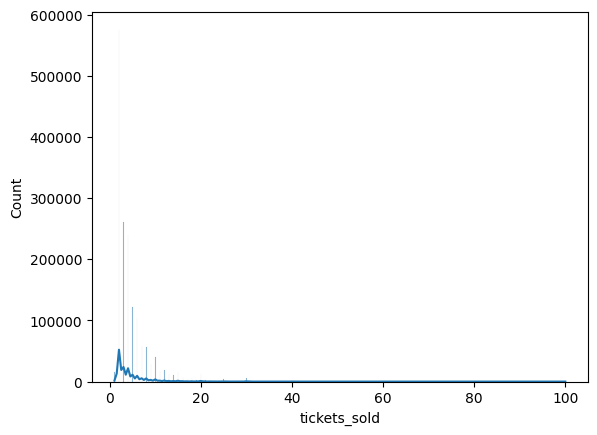

In [81]:
sns.histplot(cinePOS_booking['tickets_sold'], kde=True)


<Axes: xlabel='tickets_sold'>

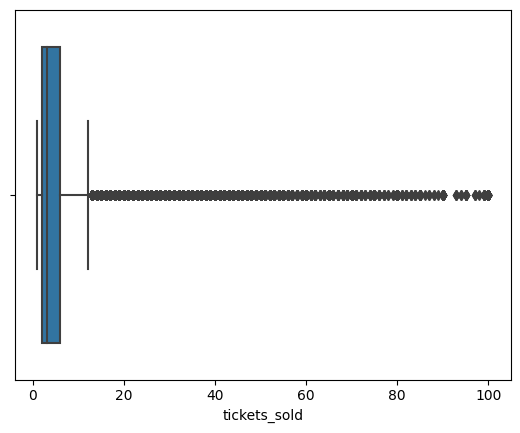

In [82]:
sns.boxplot(x=cinePOS_booking['tickets_sold'])

EDA ON CINEPOS_THEATERS

In [83]:
cinePOS_theaters.head()

,cine_theater_id,theater_type,theater_area,latitude,longitude
0,cinePOS_05466,Other,Area_104,22.619233,78.113017
1,cinePOS_08708,Other,Area_104,22.619233,78.113017
2,cinePOS_00753,Other,Area_104,22.619233,78.113017
3,cinePOS_05776,Other,Area_104,22.619233,78.113017
4,cinePOS_07536,Other,Area_104,23.004410,79.934515


In [84]:
cinePOS_theaters.shape

(4690, 5)

In [85]:
cinePOS_theaters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4690 entries, 0 to 4689
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cine_theater_id  4690 non-null   object 
 1   theater_type     4690 non-null   object 
 2   theater_area     4690 non-null   object 
 3   latitude         829 non-null    float64
 4   longitude        829 non-null    float64
dtypes: float64(2), object(3)
memory usage: 183.3+ KB


In [86]:
cinePOS_theaters['cine_theater_id'].value_counts()

cine_theater_id
cinePOS_05466    1
cinePOS_12739    1
cinePOS_05443    1
cinePOS_13124    1
cinePOS_05340    1
                ..
cinePOS_01932    1
cinePOS_00041    1
cinePOS_08283    1
cinePOS_05347    1
cinePOS_00501    1
Name: count, Length: 4690, dtype: int64

In [87]:
cinePOS_theaters['cine_theater_id'].nunique()

4690

In [88]:
cinePOS_theaters['theater_type'].value_counts()

theater_type
Other     3941
Drama      705
Action      44
Name: count, dtype: int64

In [89]:
cinePOS_theaters['theater_area'].value_counts()

theater_area
Area_119    257
Area_009    198
Area_110    163
Area_111    150
Area_145    145
           ... 
Area_214      2
Area_202      1
Area_206      1
Area_211      1
Area_213      1
Name: count, Length: 119, dtype: int64

In [90]:
cinePOS_theaters['theater_area'].nunique()

119

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='theater_area', ylabel='Count'>

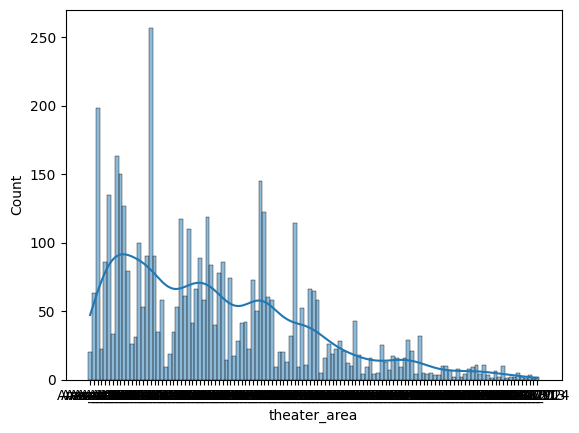

In [91]:
sns.histplot(cinePOS_theaters['theater_area'], kde=True)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='theater_type', ylabel='Count'>

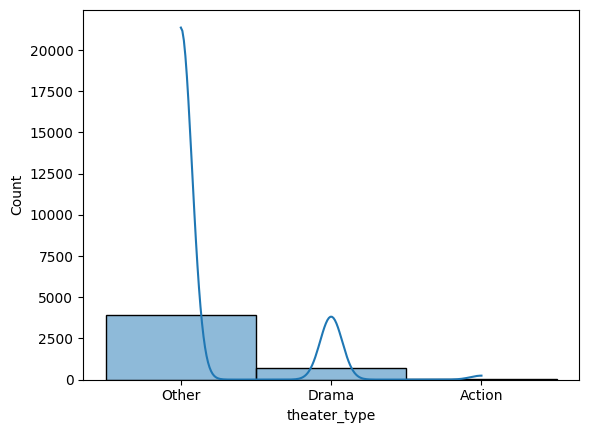

In [92]:
sns.histplot(cinePOS_theaters['theater_type'], kde=True)

In [93]:
cinePOS_booking['cine_theater_id'].nunique()

13161

In [94]:
cinePOS_theaters.head()

,cine_theater_id,theater_type,theater_area,latitude,longitude
0,cinePOS_05466,Other,Area_104,22.619233,78.113017
1,cinePOS_08708,Other,Area_104,22.619233,78.113017
2,cinePOS_00753,Other,Area_104,22.619233,78.113017
3,cinePOS_05776,Other,Area_104,22.619233,78.113017
4,cinePOS_07536,Other,Area_104,23.004410,79.934515


In [95]:
cinePOS_theaters.shape

(4690, 5)

In [96]:
cinePOS_theaters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4690 entries, 0 to 4689
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cine_theater_id  4690 non-null   object 
 1   theater_type     4690 non-null   object 
 2   theater_area     4690 non-null   object 
 3   latitude         829 non-null    float64
 4   longitude        829 non-null    float64
dtypes: float64(2), object(3)
memory usage: 183.3+ KB


In [97]:
cinePOS_theaters['theater_type'].value_counts()

theater_type
Other     3941
Drama      705
Action      44
Name: count, dtype: int64

In [98]:
cinePOS_theaters['theater_area'].value_counts()

theater_area
Area_119    257
Area_009    198
Area_110    163
Area_111    150
Area_145    145
           ... 
Area_214      2
Area_202      1
Area_206      1
Area_211      1
Area_213      1
Name: count, Length: 119, dtype: int64

In [99]:
date_info.head()

,show_date,day_of_week
0,2023-01-01,Sunday
1,2023-01-02,Monday
2,2023-01-03,Tuesday
3,2023-01-04,Wednesday
4,2023-01-05,Thursday


In [100]:
date_info.value_counts()

show_date   day_of_week
2023-01-01  Sunday         1
2024-01-03  Wednesday      1
2023-12-28  Thursday       1
2023-12-29  Friday         1
2023-12-30  Saturday       1
                          ..
2023-06-26  Monday         1
2023-06-25  Sunday         1
2023-06-24  Saturday       1
2023-06-23  Friday         1
2024-06-30  Sunday         1
Name: count, Length: 547, dtype: int64

In [101]:
date_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 547 entries, 0 to 546
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   show_date    547 non-null    object
 1   day_of_week  547 non-null    object
dtypes: object(2)
memory usage: 8.7+ KB


In [102]:
date_info.shape

(547, 2)

In [103]:
date_info['day_of_week'].value_counts()

day_of_week
Sunday       79
Monday       78
Tuesday      78
Wednesday    78
Thursday     78
Friday       78
Saturday     78
Name: count, dtype: int64

In [104]:
movie_theater_id_relation.head()

,book_theater_id,cine_theater_id
0,book_00509,cinePOS_01261
1,book_00063,cinePOS_02467
2,book_00054,cinePOS_08923
3,book_00094,cinePOS_02479
4,book_00052,cinePOS_06750


In [105]:
movie_theater_id_relation.shape

(150, 2)

In [106]:
movie_theater_id_relation['cine_theater_id'].value_counts()

cine_theater_id
cinePOS_01261    1
cinePOS_01623    1
cinePOS_11682    1
cinePOS_02027    1
cinePOS_07949    1
                ..
cinePOS_08480    1
cinePOS_02407    1
cinePOS_07044    1
cinePOS_09678    1
cinePOS_06697    1
Name: count, Length: 150, dtype: int64

In [107]:
sample_submission.head()

,ID,audience_count
0,book_00001_2024-03-01,0
1,book_00001_2024-03-02,0
2,book_00001_2024-03-03,0
3,book_00001_2024-03-04,0
4,book_00001_2024-03-06,0


### FEATURE ENGINEERING

In [108]:
# import warnings for controlling the warning messages in the output 
# importing gc to clean up unused objects from the memmory

import warnings, gc                
warnings.filterwarnings("ignore")

In [109]:
# importing numpy and padas 
import numpy as np
import pandas as pd

In [110]:

# scikit-learn tools
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import r2_score

In [111]:
# models
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
import xgboost as xgb

In [112]:

BASE = "/kaggle/input/Cinema_Audience_Forecasting_challenge"   #(base,variable assigned to prevent repeatability of the code)
fp_booknow_booking   = f"{BASE}/booknow_booking/booknow_booking.csv"
fp_booknow_theaters  = f"{BASE}/booknow_theaters/booknow_theaters.csv"
fp_booknow_visits    = f"{BASE}/booknow_visits/booknow_visits.csv"
fp_cinepos_booking   = f"{BASE}/cinePOS_booking/cinePOS_booking.csv"
fp_relation          = f"{BASE}/movie_theater_id_relation/movie_theater_id_relation.csv"
fp_date_info         = f"{BASE}/date_info/date_info.csv"
fp_sample            = f"{BASE}/sample_submission/sample_submission.csv"

In [113]:
# Reuploading the data in panda dataframe
# Load data(converting date columns in string format to actual date format)

booknow_booking = pd.read_csv(
    fp_booknow_booking,
    usecols=["book_theater_id","show_datetime","booking_datetime","tickets_booked"],
    parse_dates=["show_datetime","booking_datetime"]
)

In [114]:
booknow_booking.columns

Index(['book_theater_id', 'show_datetime', 'booking_datetime',
       'tickets_booked'],
      dtype='object')

In [115]:
booknow_booking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68336 entries, 0 to 68335
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   book_theater_id   68336 non-null  object        
 1   show_datetime     68336 non-null  datetime64[ns]
 2   booking_datetime  68336 non-null  datetime64[ns]
 3   tickets_booked    68336 non-null  int64         
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 2.1+ MB


inference - booknow_booking records bookings from the online portals
consist of 4 cols, book_theater_id indicates which theater on each booking , showdate time indicates date and time of the movie, booking_date_time indicates when customer made booking date&time, tickets_booked indicates no of tickets booked in the transaction

In [116]:

booknow_theaters = pd.read_csv(
    fp_booknow_theaters,
    usecols=["book_theater_id","theater_type","theater_area","latitude","longitude"]
)

In [117]:
booknow_theaters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829 entries, 0 to 828
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   book_theater_id  314 non-null    object 
 1   theater_type     829 non-null    object 
 2   theater_area     829 non-null    object 
 3   latitude         829 non-null    float64
 4   longitude        829 non-null    float64
dtypes: float64(2), object(3)
memory usage: 32.5+ KB


inference - provides info about each theater, consist of 5 columns book_theater_id indicates unique id of each theater , theater_type indicating type of theater, theater_area indicates the location , latitue and longitude indicates the geographical coordinates

In [118]:
booknow_visits = pd.read_csv(
    fp_booknow_visits,
    usecols=["book_theater_id","show_date","audience_count"],
    parse_dates=["show_date"]
)

In [119]:
booknow_visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214046 entries, 0 to 214045
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   book_theater_id  214046 non-null  object        
 1   show_date        214046 non-null  datetime64[ns]
 2   audience_count   214046 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 4.9+ MB


gives actual noof people who attend movie shows in each theater on each day . show date gives date when show happened, audience count is the no of peoplewho actually attended on date . its the target variable

In [120]:
cinepos_booking = pd.read_csv(
    fp_cinepos_booking,
    usecols=["cine_theater_id","show_datetime","booking_datetime","tickets_sold"],
    parse_dates=["show_datetime","booking_datetime"]
)

In [121]:
cinepos_booking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1641966 entries, 0 to 1641965
Data columns (total 4 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   cine_theater_id   1641966 non-null  object        
 1   show_datetime     1641966 non-null  datetime64[ns]
 2   booking_datetime  1641966 non-null  datetime64[ns]
 3   tickets_sold      1641966 non-null  int64         
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 50.1+ MB


inference - gives information about the ticket sold at the theater. 4 columns,
cine_theater_id is the uniqueId for each theater in cinepossysterm,tickets_sold shows the no of tickets sold in this transaction at the theater counter.

In [122]:

relation = pd.read_csv(fp_relation, usecols=["book_theater_id","cine_theater_id"])

In [123]:
relation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   book_theater_id  150 non-null    object
 1   cine_theater_id  150 non-null    object
dtypes: object(2)
memory usage: 2.5+ KB


inference - act as a bridge between cinepos(offline) and booknow(online) systems

In [124]:

date_info = pd.read_csv(fp_date_info, usecols=["show_date","day_of_week"], parse_dates=["show_date"])

In [125]:
date_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 547 entries, 0 to 546
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   show_date    547 non-null    datetime64[ns]
 1   day_of_week  547 non-null    object        
dtypes: datetime64[ns](1), object(1)
memory usage: 8.7+ KB


inference- whatday of the week each show date happens

In [126]:
sample = pd.read_csv(fp_sample)

In [127]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38062 entries, 0 to 38061
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              38062 non-null  object
 1   audience_count  38062 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 594.8+ KB


creating a function called clean_booking to covert raw data to a new data frame free from duplicates, invalid records, removing negative counts and finding the lead time. 

In [128]:
def clean_booking(df, qty_col, show_col="show_datetime", book_col="booking_datetime"):
    
    df = df.drop_duplicates().copy() # remove duplicates from the dataframe df
    
    df = df[df[book_col] <= df[show_col]]     # keep only bookings made before the show time
    
    #converting ticket count to numbers and also removes the negative counts if present
    df[qty_col] = pd.to_numeric(df[qty_col], errors="coerce").fillna(0).clip(lower=0)

    df["show_date"] = df[show_col].dt.normalize()  #remove the time parts and gives only date

    #calculating lead time which indicates how many days early booking is made(dayss)
    df["lead_time_days"] = (df[show_col] - df[book_col]).dt.total_seconds() / 86400.0

    return df


Based on the booking, divides the bookings based on the time clents have booked before the show.lets divide into
1. Same day
2. day 1 to day2
3. day 3 to 7
4. day 8 to 14
5. day above 14

In [129]:
def make_lead_buckets(df, qty_col, prefix):
    # split tickets by how early they were booked
    # df[qty_col] = no of tickets
    # prefix = catch booknow and cinepos as it contains different cols tickets_boked and tickets_sold but same meaning
    df[f"{prefix}_same_day"] = (df["lead_time_days"] <= 0.5) * df[qty_col]
    df[f"{prefix}_d1_2"]     = ((df["lead_time_days"] > 0.5) & (df["lead_time_days"] <= 2))  * df[qty_col]
    df[f"{prefix}_d3_7"]     = ((df["lead_time_days"] > 2)   & (df["lead_time_days"] <= 7))  * df[qty_col]
    df[f"{prefix}_d8_14"]    = ((df["lead_time_days"] > 7)   & (df["lead_time_days"] <= 14)) * df[qty_col]
    df[f"{prefix}_gt14"]     = (df["lead_time_days"] > 14) * df[qty_col]
    return df

In [130]:
booknow_booking = make_lead_buckets(clean_booking(booknow_booking, "tickets_booked"), "tickets_booked", "bn")
cinepos_booking  = make_lead_buckets(clean_booking(cinepos_booking,  "tickets_sold"),   "tickets_sold",  "cp")

In [131]:
booknow_booking.head()

,book_theater_id,show_datetime,booking_datetime,tickets_booked,show_date,lead_time_days,bn_same_day,bn_d1_2,bn_d3_7,bn_d8_14,bn_gt14
0,book_00244,2023-01-01 19:00:00,2023-01-01 16:00:00,1,2023-01-01,0.125000,1,0,0,0,0
1,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,3,2023-01-01,0.000000,3,0,0,0,0
2,book_00740,2023-01-01 19:00:00,2023-01-01 19:00:00,6,2023-01-01,0.000000,6,0,0,0,0
3,book_00244,2023-01-01 20:00:00,2023-01-01 16:00:00,2,2023-01-01,0.166667,2,0,0,0,0
4,book_00151,2023-01-01 20:00:00,2023-01-01 01:00:00,5,2023-01-01,0.791667,0,5,0,0,0


In [132]:
booknow_booking.columns

Index(['book_theater_id', 'show_datetime', 'booking_datetime',
       'tickets_booked', 'show_date', 'lead_time_days', 'bn_same_day',
       'bn_d1_2', 'bn_d3_7', 'bn_d8_14', 'bn_gt14'],
      dtype='object')

In [133]:
cinepos_booking.head()

,cine_theater_id,show_datetime,booking_datetime,tickets_sold,show_date,lead_time_days,cp_same_day,cp_d1_2,cp_d3_7,cp_d8_14,cp_gt14
0,cinePOS_00001,2023-01-01 11:00:00,2023-01-01 09:00:00,1,2023-01-01,0.083333,1,0,0,0,0
1,cinePOS_00002,2023-01-01 13:00:00,2023-01-01 06:00:00,3,2023-01-01,0.291667,3,0,0,0,0
2,cinePOS_00003,2023-01-01 16:00:00,2023-01-01 14:00:00,2,2023-01-01,0.083333,2,0,0,0,0
3,cinePOS_00004,2023-01-01 17:00:00,2023-01-01 11:00:00,5,2023-01-01,0.250000,5,0,0,0,0
4,cinePOS_00005,2023-01-01 17:00:00,2023-01-01 03:00:00,13,2023-01-01,0.583333,0,13,0,0,0


In [134]:
cinepos_booking.columns

Index(['cine_theater_id', 'show_datetime', 'booking_datetime', 'tickets_sold',
       'show_date', 'lead_time_days', 'cp_same_day', 'cp_d1_2', 'cp_d3_7',
       'cp_d8_14', 'cp_gt14'],
      dtype='object')

summarizing all book transactions for each theater on each showdate

### Aggregation

In [135]:

# daily aggregates for each theater and date
bn_daily = (
    booknow_booking.groupby(["book_theater_id","show_date"], as_index=False)
      .agg(bn_tickets=("tickets_booked","sum"),
           bn_bookings=("tickets_booked","count"),
           bn_lead_mean=("lead_time_days","mean"),
           bn_same_day=("bn_same_day","sum"),
           bn_d1_2=("bn_d1_2","sum"),
           bn_d3_7=("bn_d3_7","sum"),
           bn_d8_14=("bn_d8_14","sum"),
           bn_gt14=("bn_gt14","sum"))
)
#bn_tickets = total tickets sold that day
#bn_bookings = how many bookings made that day
#bn_lead_mean = average lead time for thatday
#bn_same_day to bn_gt_14 = total no of tickets that fall into each booking time

In [136]:
bn_daily.head()


,book_theater_id,show_date,bn_tickets,bn_bookings,bn_lead_mean,bn_same_day,bn_d1_2,bn_d3_7,bn_d8_14,bn_gt14
0,book_00004,2023-02-27,12,1,0.041667,12,0,0,0,0
1,book_00013,2023-01-04,2,1,0.166667,2,0,0,0,0
2,book_00013,2023-01-08,3,1,2.208333,0,0,3,0,0
3,book_00013,2023-01-09,25,12,2.878472,4,9,9,3,0
4,book_00013,2023-01-10,5,2,2.187500,2,0,3,0,0


In [137]:
bn_daily.columns

Index(['book_theater_id', 'show_date', 'bn_tickets', 'bn_bookings',
       'bn_lead_mean', 'bn_same_day', 'bn_d1_2', 'bn_d3_7', 'bn_d8_14',
       'bn_gt14'],
      dtype='object')

linking cinepos ids to matching booknow theater ids 

In [138]:
# map cinePOS theaters to booknow theaters
cp_map = cinepos_booking.merge(relation, on="cine_theater_id", how="left").dropna(subset=["book_theater_id"])



In [139]:
cp_map.head()

,cine_theater_id,show_datetime,booking_datetime,tickets_sold,show_date,lead_time_days,cp_same_day,cp_d1_2,cp_d3_7,cp_d8_14,cp_gt14,book_theater_id
102,cinePOS_00091,2023-01-01 19:00:00,2023-01-01 15:00:00,4,2023-01-01,0.166667,4,0,0,0,0,book_00151
120,cinePOS_00106,2023-01-01 19:00:00,2023-01-01 16:00:00,2,2023-01-01,0.125000,2,0,0,0,0,book_00738
270,cinePOS_00237,2023-01-02 17:00:00,2023-01-01 22:00:00,3,2023-01-02,0.791667,0,3,0,0,0,book_00093
346,cinePOS_00296,2023-01-02 18:00:00,2023-01-02 17:00:00,2,2023-01-02,0.041667,2,0,0,0,0,book_00028
347,cinePOS_00296,2023-01-02 18:00:00,2023-01-01 20:00:00,2,2023-01-02,0.916667,0,2,0,0,0,book_00028


 aggregate CinePOS bookings per theater per day by building cp_daily

In [140]:
cp_daily = (
    cp_map.groupby(["book_theater_id","show_date"], as_index=False)
      .agg(cp_tickets=("tickets_sold","sum"),
           cp_bookings=("tickets_sold","count"),
           cp_lead_mean=("lead_time_days","mean"),
           cp_same_day=("cp_same_day","sum"),
           cp_d1_2=("cp_d1_2","sum"),
           cp_d3_7=("cp_d3_7","sum"),
           cp_d8_14=("cp_d8_14","sum"),
           cp_gt14=("cp_gt14","sum"))
)

In [141]:
cp_daily.head()

,book_theater_id,show_date,cp_tickets,cp_bookings,cp_lead_mean,cp_same_day,cp_d1_2,cp_d3_7,cp_d8_14,cp_gt14
0,book_00015,2023-03-28,2,1,2.125000,0,0,2,0,0
1,book_00015,2023-04-02,2,1,5.791667,0,0,2,0,0
2,book_00015,2023-04-09,3,1,5.000000,0,0,3,0,0
3,book_00015,2023-04-12,2,1,1.916667,0,2,0,0,0
4,book_00015,2023-04-15,2,1,12.958333,0,0,0,2,0


extracting the weekend days.

In [142]:

date_info["show_date"] = date_info["show_date"].dt.normalize()


In [143]:



date_info["is_weekend"] = date_info["day_of_week"].isin(["Saturday","Sunday"]).astype(int)
date_info.head()

,show_date,day_of_week,is_weekend
0,2023-01-01,Sunday,1
1,2023-01-02,Monday,0
2,2023-01-03,Tuesday,0
3,2023-01-04,Wednesday,0
4,2023-01-05,Thursday,0


In [144]:
import pandas as pd

In [145]:
sample.head()

,ID,audience_count
0,book_00001_2024-03-01,0
1,book_00001_2024-03-02,0
2,book_00001_2024-03-03,0
3,book_00001_2024-03-04,0
4,book_00001_2024-03-06,0


In [146]:

# extracting only date  from ID   (documentaion=Series.str.extract(pat, flags=0, expand=True)

sample["show_date"] = pd.to_datetime(sample["ID"].str.extract(r"(\d{4}-\d{2}-\d{2})")[0])

#removing date time part from ID 
sample["book_theater_id"] = sample["ID"].str.replace(r"_\d{4}-\d{2}-\d{2}$","", regex=True)

In [147]:
sample['show_date']

0       2024-03-01
1       2024-03-02
2       2024-03-03
3       2024-03-04
4       2024-03-06
           ...    
38057   2024-04-18
38058   2024-04-19
38059   2024-04-20
38060   2024-04-21
38061   2024-04-22
Name: show_date, Length: 38062, dtype: datetime64[ns]

In [148]:
sample['book_theater_id']

0        book_00001
1        book_00001
2        book_00001
3        book_00001
4        book_00001
            ...    
38057    book_00829
38058    book_00829
38059    book_00829
38060    book_00829
38061    book_00829
Name: book_theater_id, Length: 38062, dtype: object

In [149]:
sample.head()

,ID,audience_count,show_date,book_theater_id
0,book_00001_2024-03-01,0,2024-03-01,book_00001
1,book_00001_2024-03-02,0,2024-03-02,book_00001
2,book_00001_2024-03-03,0,2024-03-03,book_00001
3,book_00001_2024-03-04,0,2024-03-04,book_00001
4,book_00001_2024-03-06,0,2024-03-06,book_00001


creating two small DataFrames — one for training and one for test.

In [150]:
train_keys = booknow_visits[["book_theater_id","show_date","audience_count"]].copy()
train_keys["is_kaggle_test"] = 0

test_keys = sample[["book_theater_id","show_date"]].copy()
test_keys["is_kaggle_test"] = 1

In [151]:
train_keys.head()

,book_theater_id,show_date,audience_count,is_kaggle_test
0,book_00001,2023-01-13,50,0
1,book_00001,2023-01-14,64,0
2,book_00001,2023-01-15,58,0
3,book_00001,2023-01-16,44,0
4,book_00001,2023-01-18,12,0


In [152]:
test_keys.head()

,book_theater_id,show_date,is_kaggle_test
0,book_00001,2024-03-01,1
1,book_00001,2024-03-02,1
2,book_00001,2024-03-03,1
3,book_00001,2024-03-04,1
4,book_00001,2024-03-06,1


is_kaggle_test helps to distinguish between test and train data

combine the training and test keys into one DataFrame so we can build features for both at the same time.

In [153]:
keys = pd.concat([train_keys, test_keys], ignore_index=True)
keys["show_date"] = pd.to_datetime(keys["show_date"]).dt.normalize()  #documentation=https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.normalize.html

In [154]:
keys.head()

,book_theater_id,show_date,audience_count,is_kaggle_test
0,book_00001,2023-01-13,50.0,0
1,book_00001,2023-01-14,64.0,0
2,book_00001,2023-01-15,58.0,0
3,book_00001,2023-01-16,44.0,0
4,book_00001,2023-01-18,12.0,0


merging all the useful information — from BookNow, CinePOS, date info, and theater details — into one master table called feat.

In [155]:
feat = (
    keys.merge(bn_daily, on=["book_theater_id","show_date"], how="left")
    
    # joining keys and bn_daily using book theater id and show date
        .merge(cp_daily, on=["book_theater_id","show_date"], how="left")
    
    #joining keys and cp_daily using book theater id andshow date
        .merge(date_info, on="show_date", how="left")
    
    #joining  keys and date_info using show date
        .merge(booknow_theaters, on="book_theater_id", how="left")
    
    #joining keys and book_now_theaters using booktheater id
)

In [156]:
feat.head()

,book_theater_id,show_date,audience_count,is_kaggle_test,bn_tickets,bn_bookings,bn_lead_mean,bn_same_day,bn_d1_2,bn_d3_7,...,cp_d1_2,cp_d3_7,cp_d8_14,cp_gt14,day_of_week,is_weekend,theater_type,theater_area,latitude,longitude
0,book_00001,2023-01-13,50.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Friday,0,Drama,Area_002,23.00441,79.934515
1,book_00001,2023-01-14,64.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Saturday,1,Drama,Area_002,23.00441,79.934515
2,book_00001,2023-01-15,58.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Sunday,1,Drama,Area_002,23.00441,79.934515
3,book_00001,2023-01-16,44.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Monday,0,Drama,Area_002,23.00441,79.934515
4,book_00001,2023-01-18,12.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Wednesday,0,Drama,Area_002,23.00441,79.934515


ensures that all our numeric columns are truly numeric.

In [157]:
# convert selected columns to numeric
for col in ["bn_tickets","bn_bookings","bn_lead_mean","bn_same_day","bn_d1_2","bn_d3_7","bn_d8_14","bn_gt14",
            "cp_tickets","cp_bookings","cp_lead_mean","cp_same_day","cp_d1_2","cp_d3_7","cp_d8_14","cp_gt14",
            "latitude","longitude","audience_count"]:
    feat[col] = pd.to_numeric(feat.get(col, 0), errors="coerce")

In [158]:
feat.head()

,book_theater_id,show_date,audience_count,is_kaggle_test,bn_tickets,bn_bookings,bn_lead_mean,bn_same_day,bn_d1_2,bn_d3_7,...,cp_d1_2,cp_d3_7,cp_d8_14,cp_gt14,day_of_week,is_weekend,theater_type,theater_area,latitude,longitude
0,book_00001,2023-01-13,50.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Friday,0,Drama,Area_002,23.00441,79.934515
1,book_00001,2023-01-14,64.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Saturday,1,Drama,Area_002,23.00441,79.934515
2,book_00001,2023-01-15,58.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Sunday,1,Drama,Area_002,23.00441,79.934515
3,book_00001,2023-01-16,44.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Monday,0,Drama,Area_002,23.00441,79.934515
4,book_00001,2023-01-18,12.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Wednesday,0,Drama,Area_002,23.00441,79.934515


In [159]:

# fill categories with string values
feat["day_of_week"]  = feat["day_of_week"].astype(str).fillna("Unknown")
feat["theater_type"] = feat["theater_type"].astype(str).fillna("Unknown")
feat["theater_area"] = feat["theater_area"].astype(str).fillna("Unknown")

all the tickets sold for that theater on that day: total_tix = total audience tickets (online + offline)
bn_tickets = online bookings (BookNow)

cp_tickets = offline sales (CinePOS)

In [160]:
# simple numeric features
feat["total_tix"]    = feat["bn_tickets"].fillna(0) + feat["cp_tickets"].fillna(0)


#what percentage of total tickets came from online bookings (onlinetickets/offlinetickets)

feat["online_share"] = np.where(feat["total_tix"]>0, feat["bn_tickets"].fillna(0)/feat["total_tix"], 0.0)



#ratio of CinePOS tickets to BookNow tickets (offline : online)

feat["cp_to_bn"]     = np.where(feat["bn_tickets"].fillna(0)>0,
                                feat["cp_tickets"].fillna(0)/feat["bn_tickets"].fillna(1), 0.0)


In [161]:
feat.head()

,book_theater_id,show_date,audience_count,is_kaggle_test,bn_tickets,bn_bookings,bn_lead_mean,bn_same_day,bn_d1_2,bn_d3_7,...,cp_gt14,day_of_week,is_weekend,theater_type,theater_area,latitude,longitude,total_tix,online_share,cp_to_bn
0,book_00001,2023-01-13,50.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Friday,0,Drama,Area_002,23.00441,79.934515,0.0,0.0,0.0
1,book_00001,2023-01-14,64.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Saturday,1,Drama,Area_002,23.00441,79.934515,0.0,0.0,0.0
2,book_00001,2023-01-15,58.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Sunday,1,Drama,Area_002,23.00441,79.934515,0.0,0.0,0.0
3,book_00001,2023-01-16,44.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Monday,0,Drama,Area_002,23.00441,79.934515,0.0,0.0,0.0
4,book_00001,2023-01-18,12.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Wednesday,0,Drama,Area_002,23.00441,79.934515,0.0,0.0,0.0


In [162]:
feat.columns

Index(['book_theater_id', 'show_date', 'audience_count', 'is_kaggle_test',
       'bn_tickets', 'bn_bookings', 'bn_lead_mean', 'bn_same_day', 'bn_d1_2',
       'bn_d3_7', 'bn_d8_14', 'bn_gt14', 'cp_tickets', 'cp_bookings',
       'cp_lead_mean', 'cp_same_day', 'cp_d1_2', 'cp_d3_7', 'cp_d8_14',
       'cp_gt14', 'day_of_week', 'is_weekend', 'theater_type', 'theater_area',
       'latitude', 'longitude', 'total_tix', 'online_share', 'cp_to_bn'],
      dtype='object')

calculating share of tickets sold in each time bucket

In [163]:

for side in ["bn","cp"]:            #for loop for booknow and cinepos
    
    total = f"{side}_tickets"       #total become bn_tickets or cp_tickets
    
    for part in [f"{side}_same_day", f"{side}_d1_2", f"{side}_d3_7", f"{side}_d8_14", f"{side}_gt14"]:

        #share of tickets for specific time bucket = share = tickets in the bucket/total tickets
        
        feat[f"{part}_share"] = np.where(feat[total].fillna(0)>0,
                                         feat[part].fillna(0)/feat[total].fillna(1), 0.0)    

In [164]:
feat.head()

,book_theater_id,show_date,audience_count,is_kaggle_test,bn_tickets,bn_bookings,bn_lead_mean,bn_same_day,bn_d1_2,bn_d3_7,...,bn_same_day_share,bn_d1_2_share,bn_d3_7_share,bn_d8_14_share,bn_gt14_share,cp_same_day_share,cp_d1_2_share,cp_d3_7_share,cp_d8_14_share,cp_gt14_share
0,book_00001,2023-01-13,50.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,book_00001,2023-01-14,64.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,book_00001,2023-01-15,58.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,book_00001,2023-01-16,44.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,book_00001,2023-01-18,12.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Time series feature engineering

creates 6 new columns from the show_date column.

In [165]:
#Convert show_date to a datetime object
s = pd.to_datetime(feat["show_date"])

In [166]:
s.head()

0   2023-01-13
1   2023-01-14
2   2023-01-15
3   2023-01-16
4   2023-01-18
Name: show_date, dtype: datetime64[ns]

Extract the month,Extract the week of the year,Extract the day of the year,Extract the quarter,Mark start and end of month

In [167]:
feat["month"]         = s.dt.month
feat["weekofyear"]    = s.dt.isocalendar().week.astype(int)
feat["dayofyear"]     = s.dt.dayofyear
feat["quarter"]       = s.dt.quarter
feat["is_month_start"]= s.dt.is_month_start.astype(int)
feat["is_month_end"]  = s.dt.is_month_end.astype(int)

In [168]:
feat.head()

,book_theater_id,show_date,audience_count,is_kaggle_test,bn_tickets,bn_bookings,bn_lead_mean,bn_same_day,bn_d1_2,bn_d3_7,...,cp_d1_2_share,cp_d3_7_share,cp_d8_14_share,cp_gt14_share,month,weekofyear,dayofyear,quarter,is_month_start,is_month_end
0,book_00001,2023-01-13,50.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1,2,13,1,0,0
1,book_00001,2023-01-14,64.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1,2,14,1,0,0
2,book_00001,2023-01-15,58.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1,2,15,1,0,0
3,book_00001,2023-01-16,44.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1,3,16,1,0,0
4,book_00001,2023-01-18,12.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1,3,18,1,0,0


In [169]:
feat.columns

Index(['book_theater_id', 'show_date', 'audience_count', 'is_kaggle_test',
       'bn_tickets', 'bn_bookings', 'bn_lead_mean', 'bn_same_day', 'bn_d1_2',
       'bn_d3_7', 'bn_d8_14', 'bn_gt14', 'cp_tickets', 'cp_bookings',
       'cp_lead_mean', 'cp_same_day', 'cp_d1_2', 'cp_d3_7', 'cp_d8_14',
       'cp_gt14', 'day_of_week', 'is_weekend', 'theater_type', 'theater_area',
       'latitude', 'longitude', 'total_tix', 'online_share', 'cp_to_bn',
       'bn_same_day_share', 'bn_d1_2_share', 'bn_d3_7_share', 'bn_d8_14_share',
       'bn_gt14_share', 'cp_same_day_share', 'cp_d1_2_share', 'cp_d3_7_share',
       'cp_d8_14_share', 'cp_gt14_share', 'month', 'weekofyear', 'dayofyear',
       'quarter', 'is_month_start', 'is_month_end'],
      dtype='object')

sorts the data in proper time order for each theater

In [170]:
feat = feat.sort_values(["book_theater_id","show_date"]).reset_index(drop=True)

In [171]:
feat.head()

,book_theater_id,show_date,audience_count,is_kaggle_test,bn_tickets,bn_bookings,bn_lead_mean,bn_same_day,bn_d1_2,bn_d3_7,...,cp_d1_2_share,cp_d3_7_share,cp_d8_14_share,cp_gt14_share,month,weekofyear,dayofyear,quarter,is_month_start,is_month_end
0,book_00001,2023-01-13,50.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1,2,13,1,0,0
1,book_00001,2023-01-14,64.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1,2,14,1,0,0
2,book_00001,2023-01-15,58.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1,2,15,1,0,0
3,book_00001,2023-01-16,44.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1,3,16,1,0,0
4,book_00001,2023-01-18,12.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1,3,18,1,0,0


calculating the average audience count so far for each theater.

average keeps growing by including all past values up to today, so it is an expanding average

In [172]:
#calculates an expanding average of past audiences for each theater.

exp_mean_list = []

# Loop through each theater one by one
for t_id, group in feat.groupby("book_theater_id"):
    # Sort by date
    group = group.sort_values("show_date")
    
    # shifts the audience values by one day to avoid using future data
    shifted = group["audience_count"].shift(1)
    
    # Create expanding average (only starts after 5 days)
    expanding_avg = shifted.expanding(min_periods=5).mean()
    
    # Save results
    exp_mean_list.append(expanding_avg)

# Combine everything into one series
exp_mean = pd.concat(exp_mean_list).sort_index()


In [173]:
exp_mean

0               NaN
1               NaN
2               NaN
3               NaN
4               NaN
            ...    
252103    11.147368
252104    11.147368
252105    11.147368
252106    11.147368
252107    11.147368
Name: audience_count, Length: 252108, dtype: float64

In [174]:
exp_mean.value_counts()

audience_count
22.000000    225
20.000000    153
24.000000    147
26.000000    140
30.000000    119
            ... 
47.912409      1
48.014706      1
47.849624      1
47.742424      1
60.035088      1
Name: count, Length: 143384, dtype: int64

lag features and rolling average features

In [175]:
feat["exp_mean_shift"] = exp_mean  #Add the previously calculated expanding mean


#Lag feature = how many people came to this theater x days before

feat["ac_lag7"]  = feat.groupby("book_theater_id")["audience_count"].shift(7) #7-day lag feature(1 week)
feat["ac_lag14"] = feat.groupby("book_theater_id")["audience_count"].shift(14)  #14-day lag feature(2 week)

In [176]:
feat.head()

,book_theater_id,show_date,audience_count,is_kaggle_test,bn_tickets,bn_bookings,bn_lead_mean,bn_same_day,bn_d1_2,bn_d3_7,...,cp_gt14_share,month,weekofyear,dayofyear,quarter,is_month_start,is_month_end,exp_mean_shift,ac_lag7,ac_lag14
0,book_00001,2023-01-13,50.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1,2,13,1,0,0,NaN,NaN,NaN
1,book_00001,2023-01-14,64.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1,2,14,1,0,0,NaN,NaN,NaN
2,book_00001,2023-01-15,58.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1,2,15,1,0,0,NaN,NaN,NaN
3,book_00001,2023-01-16,44.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1,3,16,1,0,0,NaN,NaN,NaN
4,book_00001,2023-01-18,12.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1,3,18,1,0,0,NaN,NaN,NaN


In [177]:
#7-day rolling average (short-term trend)
feat["ac_roll7"] = (
    feat.groupby("book_theater_id")["audience_count"]
        .apply(lambda x: x.shift(1).rolling(7, min_periods=4).mean())
        .reset_index(level=0, drop=True)
)


In [178]:
#28-day rolling average (long-term trend)

feat["ac_roll28"] = (
    feat.groupby("book_theater_id")["audience_count"]
        .apply(lambda x: x.shift(1).rolling(28, min_periods=7).mean())
        .reset_index(level=0, drop=True)
)

fills in missing values (NaN) in the lag and rolling columns we created earlier
using the exp_mean_shift column

In [179]:
for c in ["ac_lag7","ac_lag14","ac_roll7","ac_roll28"]:
    feat[c] = feat[c].fillna(feat["exp_mean_shift"])


exp_mean_shift helped us fill missing values in other columns (ac_lag7, ac_lag14, ac_roll7, ac_roll28).
as it is fullfilled , it is removed for getting clean datasets.

In [180]:
feat = feat.drop(columns=["exp_mean_shift"])

In [181]:
feat.head()

,book_theater_id,show_date,audience_count,is_kaggle_test,bn_tickets,bn_bookings,bn_lead_mean,bn_same_day,bn_d1_2,bn_d3_7,...,month,weekofyear,dayofyear,quarter,is_month_start,is_month_end,ac_lag7,ac_lag14,ac_roll7,ac_roll28
0,book_00001,2023-01-13,50.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1,2,13,1,0,0,NaN,NaN,NaN,NaN
1,book_00001,2023-01-14,64.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1,2,14,1,0,0,NaN,NaN,NaN,NaN
2,book_00001,2023-01-15,58.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1,2,15,1,0,0,NaN,NaN,NaN,NaN
3,book_00001,2023-01-16,44.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1,3,16,1,0,0,NaN,NaN,NaN,NaN
4,book_00001,2023-01-18,12.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1,3,18,1,0,0,NaN,NaN,54.0,NaN


### Training and Test split

In [182]:
TARGET  = "audience_count"    #the thing we want to predict
ID_COLS = ["book_theater_id","show_date","is_kaggle_test"]   #the columns we don’t want the model to learn from

In [183]:
ID_COLS, TARGET

(['book_theater_id', 'show_date', 'is_kaggle_test'], 'audience_count')

splitting the dataset in to train and test dataset

In [184]:

train_df = feat[feat["is_kaggle_test"]==0].copy()
test_df  = feat[feat["is_kaggle_test"]==1].copy()


In [185]:
train_df.head()

,book_theater_id,show_date,audience_count,is_kaggle_test,bn_tickets,bn_bookings,bn_lead_mean,bn_same_day,bn_d1_2,bn_d3_7,...,month,weekofyear,dayofyear,quarter,is_month_start,is_month_end,ac_lag7,ac_lag14,ac_roll7,ac_roll28
0,book_00001,2023-01-13,50.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1,2,13,1,0,0,NaN,NaN,NaN,NaN
1,book_00001,2023-01-14,64.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1,2,14,1,0,0,NaN,NaN,NaN,NaN
2,book_00001,2023-01-15,58.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1,2,15,1,0,0,NaN,NaN,NaN,NaN
3,book_00001,2023-01-16,44.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1,3,16,1,0,0,NaN,NaN,NaN,NaN
4,book_00001,2023-01-18,12.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1,3,18,1,0,0,NaN,NaN,54.0,NaN


In [186]:
test_df.head()

,book_theater_id,show_date,audience_count,is_kaggle_test,bn_tickets,bn_bookings,bn_lead_mean,bn_same_day,bn_d1_2,bn_d3_7,...,month,weekofyear,dayofyear,quarter,is_month_start,is_month_end,ac_lag7,ac_lag14,ac_roll7,ac_roll28
342,book_00001,2024-03-01,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,...,3,9,61,1,1,0,28.0,34.0,38.857143,37.071429
343,book_00001,2024-03-02,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,...,3,9,62,1,0,0,50.0,30.0,40.666667,38.148148
344,book_00001,2024-03-03,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,...,3,9,63,1,0,0,22.0,32.0,38.800000,38.692308
345,book_00001,2024-03-04,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,...,3,10,64,1,0,0,80.0,78.0,43.000000,39.440000
346,book_00001,2024-03-06,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,...,3,10,66,1,0,0,54.0,44.0,47.058480,39.500000


helping the model understand which columns are numbers and which are categories (text labels).

In [187]:
cat_cols = ["day_of_week","theater_type","theater_area"]
num_cols = [c for c in feat.columns if c not in ID_COLS + [TARGET] + cat_cols]


In [188]:
cat_cols, num_cols

(['day_of_week', 'theater_type', 'theater_area'],
 ['bn_tickets',
  'bn_bookings',
  'bn_lead_mean',
  'bn_same_day',
  'bn_d1_2',
  'bn_d3_7',
  'bn_d8_14',
  'bn_gt14',
  'cp_tickets',
  'cp_bookings',
  'cp_lead_mean',
  'cp_same_day',
  'cp_d1_2',
  'cp_d3_7',
  'cp_d8_14',
  'cp_gt14',
  'is_weekend',
  'latitude',
  'longitude',
  'total_tix',
  'online_share',
  'cp_to_bn',
  'bn_same_day_share',
  'bn_d1_2_share',
  'bn_d3_7_share',
  'bn_d8_14_share',
  'bn_gt14_share',
  'cp_same_day_share',
  'cp_d1_2_share',
  'cp_d3_7_share',
  'cp_d8_14_share',
  'cp_gt14_share',
  'month',
  'weekofyear',
  'dayofyear',
  'quarter',
  'is_month_start',
  'is_month_end',
  'ac_lag7',
  'ac_lag14',
  'ac_roll7',
  'ac_roll28'])



#Converts whatever is in the column into numbers (integers or floats). if something can’t be converted to a number



In [189]:


#Converts whatever is in the column into numbers (integers or floats). if something can’t be converted to a number

for c in num_cols:
    train_df[c] = pd.to_numeric(train_df[c], errors="coerce")
    test_df[c]  = pd.to_numeric(test_df[c], errors="coerce")

In [190]:
train_df.head()

,book_theater_id,show_date,audience_count,is_kaggle_test,bn_tickets,bn_bookings,bn_lead_mean,bn_same_day,bn_d1_2,bn_d3_7,...,month,weekofyear,dayofyear,quarter,is_month_start,is_month_end,ac_lag7,ac_lag14,ac_roll7,ac_roll28
0,book_00001,2023-01-13,50.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1,2,13,1,0,0,NaN,NaN,NaN,NaN
1,book_00001,2023-01-14,64.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1,2,14,1,0,0,NaN,NaN,NaN,NaN
2,book_00001,2023-01-15,58.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1,2,15,1,0,0,NaN,NaN,NaN,NaN
3,book_00001,2023-01-16,44.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1,3,16,1,0,0,NaN,NaN,NaN,NaN
4,book_00001,2023-01-18,12.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1,3,18,1,0,0,NaN,NaN,54.0,NaN


In [191]:
test_df.head()

,book_theater_id,show_date,audience_count,is_kaggle_test,bn_tickets,bn_bookings,bn_lead_mean,bn_same_day,bn_d1_2,bn_d3_7,...,month,weekofyear,dayofyear,quarter,is_month_start,is_month_end,ac_lag7,ac_lag14,ac_roll7,ac_roll28
342,book_00001,2024-03-01,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,...,3,9,61,1,1,0,28.0,34.0,38.857143,37.071429
343,book_00001,2024-03-02,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,...,3,9,62,1,0,0,50.0,30.0,40.666667,38.148148
344,book_00001,2024-03-03,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,...,3,9,63,1,0,0,22.0,32.0,38.800000,38.692308
345,book_00001,2024-03-04,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,...,3,10,64,1,0,0,80.0,78.0,43.000000,39.440000
346,book_00001,2024-03-06,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,...,3,10,66,1,0,0,54.0,44.0,47.058480,39.500000


In [192]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 214046 entries, 0 to 252063
Data columns (total 49 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   book_theater_id    214046 non-null  object        
 1   show_date          214046 non-null  datetime64[ns]
 2   audience_count     214046 non-null  float64       
 3   is_kaggle_test     214046 non-null  int64         
 4   bn_tickets         21041 non-null   float64       
 5   bn_bookings        21041 non-null   float64       
 6   bn_lead_mean       21041 non-null   float64       
 7   bn_same_day        21041 non-null   float64       
 8   bn_d1_2            21041 non-null   float64       
 9   bn_d3_7            21041 non-null   float64       
 10  bn_d8_14           21041 non-null   float64       
 11  bn_gt14            21041 non-null   float64       
 12  cp_tickets         11150 non-null   float64       
 13  cp_bookings        11150 non-null   float64      

In [193]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38062 entries, 342 to 252107
Data columns (total 49 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   book_theater_id    38062 non-null  object        
 1   show_date          38062 non-null  datetime64[ns]
 2   audience_count     0 non-null      float64       
 3   is_kaggle_test     38062 non-null  int64         
 4   bn_tickets         0 non-null      float64       
 5   bn_bookings        0 non-null      float64       
 6   bn_lead_mean       0 non-null      float64       
 7   bn_same_day        0 non-null      float64       
 8   bn_d1_2            0 non-null      float64       
 9   bn_d3_7            0 non-null      float64       
 10  bn_d8_14           0 non-null      float64       
 11  bn_gt14            0 non-null      float64       
 12  cp_tickets         0 non-null      float64       
 13  cp_bookings        0 non-null      float64       
 14  cp_lead_

### Preprocessing

Applying a column transformer to fills missing numeric values with the median, converts categorical columns to numerical using OneHotEncoding, drops unnecessary columns, and keeps the output feature names simple.”

In [194]:
pre = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

In [195]:
pre

ColumnTransformer(transformers=[('num', SimpleImputer(strategy='median'),
                                 ['bn_tickets', 'bn_bookings', 'bn_lead_mean',
                                  'bn_same_day', 'bn_d1_2', 'bn_d3_7',
                                  'bn_d8_14', 'bn_gt14', 'cp_tickets',
                                  'cp_bookings', 'cp_lead_mean', 'cp_same_day',
                                  'cp_d1_2', 'cp_d3_7', 'cp_d8_14', 'cp_gt14',
                                  'is_weekend', 'latitude', 'longitude',
                                  'total_tix', 'online_share', 'cp_to_bn',
                                  'bn_same_day_share', 'bn_d1_2_share',
                                  'bn_d3_7_share', 'bn_d8_14_share',
                                  'bn_gt14_share', 'cp_same_day_share',
                                  'cp_d1_2_share', 'cp_d3_7_share', ...]),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse=False),
                                 ['day_of_week', 'theater_type',
                                  'theater_area'])],
                  verbose_feature_names_out=False)

### Model Building

Model 1 = Light GBM

In [196]:
lgb_base = lgb.LGBMRegressor(
    objective="rmse",
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=110,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

In [197]:
lgb_base

LGBMRegressor(colsample_bytree=0.85, learning_rate=0.05, min_child_samples=110,
              n_estimators=2000, n_jobs=-1, objective='rmse', random_state=42,
              reg_lambda=1.0, subsample=0.85)

Model 2 =Random Forest Regressor

In [198]:

rf_base = RandomForestRegressor(
    n_estimators=400,
    max_depth=18,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
)

In [199]:
rf_base

RandomForestRegressor(max_depth=18, min_samples_leaf=2, n_estimators=400,
                      n_jobs=-1, random_state=42)

Model 3 = XGB Regressor

In [200]:
xgb_base = xgb.XGBRegressor(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="reg:squarederror",
    n_jobs=-1,
    random_state=42,
)

In [201]:
xgb_base

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=800, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

Make pipelines for each model ,created three pipelines — one for LightGBM, one for RandomForest, and one for XGBoost —all share the same preprocessing step

In [202]:
lgb_pipe = Pipeline([("preprocess", pre), ("model", lgb_base)])
rf_pipe  = Pipeline([("preprocess", pre), ("model", rf_base)])
xgb_pipe = Pipeline([("preprocess", pre), ("model", xgb_base)])

In [203]:
models = {
    "lightgbm": lgb_pipe,
    "random_forest": rf_pipe,
    "xgboost": xgb_pipe
}

In [204]:
train_df = train_df.sort_values("show_date")  #sort because time-series models

In [205]:
train_df.head()

,book_theater_id,show_date,audience_count,is_kaggle_test,bn_tickets,bn_bookings,bn_lead_mean,bn_same_day,bn_d1_2,bn_d3_7,...,month,weekofyear,dayofyear,quarter,is_month_start,is_month_end,ac_lag7,ac_lag14,ac_roll7,ac_roll28
42129,book_00140,2023-01-01,22.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1,52,1,1,1,0,NaN,NaN,NaN,NaN
139665,book_00463,2023-01-01,24.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1,52,1,1,1,0,NaN,NaN,NaN,NaN
246429,book_00812,2023-01-01,8.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1,52,1,1,1,0,NaN,NaN,NaN,NaN
131958,book_00437,2023-01-01,32.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1,52,1,1,1,0,NaN,NaN,NaN,NaN
124877,book_00414,2023-01-01,14.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1,52,1,1,1,0,NaN,NaN,NaN,NaN


Extract all months present in the dataset

In [206]:
all_months = train_df["show_date"].dt.to_period("M").unique()  #documentation=https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.to_period.html


In [207]:
all_months

<PeriodArray>
['2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06', '2023-07',
 '2023-08', '2023-09', '2023-10', '2023-11', '2023-12', '2024-01', '2024-02']
Length: 14, dtype: period[M]

Convert months to strings and sort them

In [208]:
all_months = sorted(all_months.astype(str))


In [209]:
all_months

['2023-01',
 '2023-02',
 '2023-03',
 '2023-04',
 '2023-05',
 '2023-06',
 '2023-07',
 '2023-08',
 '2023-09',
 '2023-10',
 '2023-11',
 '2023-12',
 '2024-01',
 '2024-02']

### Validation time based

Choose last 3 months as validation

In [210]:
if len(all_months) >= 3:
    val_months = all_months[-3:]   #use the last 3 months for validation
else:
    val_months = all_months[-1:]   #use whatever months are available (only 1 or 2)


check if our model can predict future months correctly.(time series cross validation)

In [211]:
def month_cv_score(pipe):
    scores = []
    
    #Check each validation month
    for vm in val_months:
        
        start = pd.Period(vm).start_time   #Find the start and end of that month
        end   = pd.Period(vm).end_time

        #Split the data in to train set and validation set
        trn = train_df[train_df["show_date"] < start]      
        val = train_df[(train_df["show_date"] >= start) & (train_df["show_date"] <= end)]

        #Skip if empty
        if trn.empty or val.empty:
              continue

        X_tr, y_tr = trn[num_cols + cat_cols], trn[TARGET]  #Get features and target
        X_va, y_va = val[num_cols + cat_cols], val[TARGET]

        #Train the model

        pipe.fit(X_tr, y_tr)

        #prediction for the month
        p = np.clip(pipe.predict(X_va), 0, None)

        #compute r2 score
        scores.append(r2_score(y_va, p))
    return np.mean(scores) if scores else np.nan


        


 cross-validation R² score for each model and stores the results in a dictionary.

In [212]:
# Create an empty dictionary to store CV scores
cv_scores = {}

# Loop through each model and calculate its month-based CV score
for model_name, model_pipe in models.items():
    score = month_cv_score(model_pipe)
    cv_scores[model_name] = score

print(" R²:", cv_scores)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041804 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4458
[LightGBM] [Info] Number of data points in the train set: 153020, number of used features: 120
[LightGBM] [Info] Start training from score 41.406391
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039058 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4822
[LightGBM] [Info] Number of data points in the train set: 174535, number of used features: 125
[LightGBM] [Info] Start training from score 42.004412
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023622 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not

R2 scores 0.503 for lightgbm, 0.4985 for random forest regressor , 0.4868 for xgboost regressor

### Fine tuning

In [213]:
# Take only the most recent 20% of training data for  tuning
cutoff_date = train_df["show_date"].quantile(0.80)

tune_df = train_df[train_df["show_date"] >= cutoff_date].copy()

# Split into features and target
X_tune = tune_df[num_cols + cat_cols]
y_tune = tune_df[TARGET]


In [214]:
X_tune

,bn_tickets,bn_bookings,bn_lead_mean,bn_same_day,bn_d1_2,bn_d3_7,bn_d8_14,bn_gt14,cp_tickets,cp_bookings,...,quarter,is_month_start,is_month_end,ac_lag7,ac_lag14,ac_roll7,ac_roll28,day_of_week,theater_type,theater_area
85697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4,0,0,8.0,4.0,10.857143,11.357143,Tuesday,Other,Area_074
72735,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4,0,0,10.0,36.0,32.857143,36.928571,Tuesday,Drama,Area_020
173937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4,0,0,46.0,64.0,66.000000,61.571429,Tuesday,nan,nan
212267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4,0,0,78.0,78.0,58.285714,75.857143,Tuesday,nan,nan
10069,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,1.0,...,4,0,0,104.0,62.0,87.142857,65.714286,Tuesday,Other,Area_061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93026,13.0,1.0,4.041667,0.0,0.0,13.0,0.0,0.0,8.0,1.0,...,1,0,0,36.0,16.0,23.714286,21.642857,Wednesday,Other,Area_094
192751,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,0,0,94.0,94.0,87.428571,77.214286,Wednesday,nan,nan
11164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,0,0,6.0,34.0,22.571429,22.857143,Wednesday,Drama,Area_007
216388,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,0,0,14.0,14.0,13.428571,11.285714,Wednesday,nan,nan


In [215]:
y_tune

85697      8.0
72735     24.0
173937    82.0
212267    78.0
10069     94.0
          ... 
93026     30.0
192751    70.0
11164     12.0
216388    18.0
252063    16.0
Name: audience_count, Length: 43198, dtype: float64

Time series split initiation

In [216]:
# Random seed for reproducibility
rng = np.random.RandomState(42)

# Use time-based cross validation
tscv = TimeSeriesSplit(n_splits=2)

 possible values for LightGBM hyperparameters.

In [217]:

lgb_params = {
    # number of leaves (tree complexity)
    "m__num_leaves": rng.randint(16, 64, size=16),

    # minimum samples required to form a leaf
    "m__min_child_samples": rng.randint(60, 160, size=16),

    # sample a fraction of training rows for each tree
    "m__subsample": rng.uniform(0.70, 0.95, size=16),

    # sample a fraction of features for each tree
    "m__colsample_bytree": rng.uniform(0.70, 0.95, size=16),

    # L2 regularization
    "m__reg_lambda": rng.uniform(0.0, 2.0, size=16),

    # a few safe learning-rate choices
    "m__learning_rate": [0.03, 0.04, 0.05, 0.06],

    # number of boosting rounds
    "m__n_estimators": [1200, 1600, 2000]
}


wrapped preprocessing and LightGBM model inside a Pipeline.

In [218]:
lgb_pipe = Pipeline([("preprocess", pre), ("model", lgb_base)])

RandomizedSearchCV to try 10 different combinations of hyperparameters.

In [219]:
lgb_search = RandomizedSearchCV(
    lgb_pipe, lgb_params, n_iter=10, cv=tscv, scoring="r2",
    n_jobs=-1, random_state=42, verbose=0
)


possible values for Random Forest hyperparameters.

In [220]:

rf_params = {
    "m__n_estimators": [300, 400, 500],
    "m__max_depth": [14, 16, 18, 20],
    "m__min_samples_leaf": [1, 2, 3],
}

wrapped preprocessing and random forest model
inside a Pipeline.

In [221]:
rf_pipe = Pipeline([("preprocess", pre), ("model", rf_base)])

RandomizedSearchCV to try 10 different combinations of hyperparameters.

In [222]:
rf_search = RandomizedSearchCV(
    rf_pipe, rf_params, n_iter=10, cv=tscv, scoring="r2",
    n_jobs=-1, random_state=42, verbose=0
)


possible values for XGBoost regressor hyperparameters.

In [223]:
# XGBoost search space
xgb_params = {
    "m__n_estimators": [600, 800, 1000],
    "m__max_depth": [4, 6, 8],
    "m__learning_rate": [0.03, 0.05, 0.07],
    "m__subsample": [0.7, 0.8, 0.9],
    "m__colsample_bytree": [0.7, 0.8, 0.9],
}

wrapped preprocessing and XGBoost model inside a Pipeline.

In [224]:
xgb_pipe = Pipeline([("preprocess", pre), ("model", xgb_base)])


RandomizedSearchCV to try 10 different combinations of hyperparameters.

In [225]:
xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_params, n_iter=10, cv=tscv, scoring="r2",
    n_jobs=-1, random_state=42, verbose=0
)

function  to tune a model, but only keeps the tuned version if it is actually better than the original model.

In [226]:
def run_small_tuning(name, base_model, tuner):


    # Get the cross-validation score of the original model
    original_score = cv_scores[name]

    try:
        # Run the small RandomizedSearchCV on the tuning data
        tuner.fit(X_tune, y_tune)

        # Best model found by RandomizedSearchCV
        tuned_model = tuner.best_estimator_

        # Check tuned model using our month-based validation
        tuned_score = month_cv_score(tuned_model)

        print(f"{name} Original: {original_score:.4f},Tuned: {tuned_score:.4f}")

        # If tuned model is worse, keep the original
        
        if (np.isnan(tuned_score)) or (tuned_score < original_score):
            print(f"{name}  Tuned model not better. Keeping original model.")
            return base_model

        # Otherwise use tuned model
        print(f"{name}  Tuned model improved performance. Using it.")
        return tuned_model

    except Exception as e:
        # If tuning fails for any reason, keep original model
        print(f"{name}  Tuning skipped due to error: {e}")
        return base_model


Try tuning each model (LightGBM, Random Forest, XGBoost).
If tuning improves the model, keep the tuned version.
If tuning makes it worse, keep the original version.

In [227]:



models["lgb_final"] = run_small_tuning("lightgbm", models["lightgbm"], lgb_search)
models["rf_final"]  = run_small_tuning("random_forest",  models["random_forest"],  rf_search)
models["xgb_final"] = run_small_tuning("xgboost", models["xgboost"], xgb_search)

lightgbm  Tuning skipped due to error: Invalid parameter 'm' for estimator Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['bn_tickets', 'bn_bookings',
                                                   'bn_lead_mean',
                                                   'bn_same_day', 'bn_d1_2',
                                                   'bn_d3_7', 'bn_d8_14',
                                                   'bn_gt14', 'cp_tickets',
                                                   'cp_bookings',
                                                   'cp_lead_mean',
                                                   'cp_same_day', 'cp_d1_2',
                                                   'cp_d3_7', 'cp_d8_14',
                                                   'cp_gt14', 'is_weekend',
                   

dictionary that contains the final version of all three models:

In [228]:
final_candidates = {
    "lgb": models["lgb_final"],
    "rf" : models["rf_final"],
    "xgb": models["xgb_final"],
}

R² score of each final model

In [229]:
final_scores = {}
for name, model in final_candidates.items():
    score = month_cv_score(model)
    final_scores[name] = score
print('Final R2:', final_scores)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.036857 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4458
[LightGBM] [Info] Number of data points in the train set: 153020, number of used features: 120
[LightGBM] [Info] Start training from score 41.406391
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039744 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4822
[LightGBM] [Info] Number of data points in the train set: 174535, number of used features: 125
[LightGBM] [Info] Start training from score 42.004412
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023871 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not

 Find the model with the highest score

In [230]:


# Find the model with the highest score
best_name = None
best_score = -1e9

for name, score in final_scores.items():
    # ignore NaN scores
    if not np.isnan(score) and score > best_score:
        best_name = name
        best_score = score

#  Prefer LightGBM if its score is very close 
lgb_score = final_scores.get("lgb", -1)

if best_name != "lgb" and abs(lgb_score - best_score) <= 0.005:
    best_name = "lgb"

#  Select that model
final_model = final_candidates[best_name]
print("Chosen model:", best_name)


Chosen model: lgb


### Final training and prediction

 Train the final model on ALL training data, then predict

In [231]:


# Separate features and target from the training set
X_train_full = train_df[num_cols + cat_cols]
y_train_full = train_df[TARGET]

# Train the chosen model on the full training data
final_model.fit(X_train_full, y_train_full)

# Predict on the test set (and force negative values to zero)
X_test_full = test_df[num_cols + cat_cols]
test_pred = final_model.predict(X_test_full)

# Clip negative predictions (audience cannot be negative)
test_pred = np.clip(test_pred, 0, None)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026007 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4878
[LightGBM] [Info] Number of data points in the train set: 214046, number of used features: 125
[LightGBM] [Info] Start training from score 41.616568


mean calibration=helps the model stay stable during Kaggle evaluation and prevents sudden drops.

test prediction = test prediction*(average of training df(y_train) / average of test prediction)

In [232]:


# Average actual audience in training data
avg_train = y_train_full.mean()

# Average predicted audience for the test set
avg_pred = test_pred.mean()

# Avoid dividing by zero
if avg_pred <= 0:
    avg_pred = 1.0

# Scale predictions so that their averages match
test_pred = test_pred * (avg_train / avg_pred)


In [233]:
avg_train,avg_pred,test_pred

(41.61656840118479,
 42.29133126245648,
 array([33.43502346, 48.98808277, 44.52070003, ..., 13.00627374,
        15.13839876, 12.31256504]))

In [234]:


# Take only the required identifier columns from test data
out = test_df[["book_theater_id", "show_date"]].copy()

# Add the predicted audience numbers
out["audience_count"] = test_pred


In [235]:
out.head()

,book_theater_id,show_date,audience_count
342,book_00001,2024-03-01,33.435023
343,book_00001,2024-03-02,48.988083
344,book_00001,2024-03-03,44.520700
345,book_00001,2024-03-04,44.628826
346,book_00001,2024-03-06,36.739110


### Submission

take the sample submission, remove its dummy numbers, merge our real predictions, and clean the final column so it’s numeric and has no missing values.

In [236]:
# Start with Kaggle sample submission format
sub = sample.copy()

# Remove the old placeholder audience_count column
sub = sub.drop(columns=["audience_count"], errors="ignore")

# Merge our predictions into the same format as the sample file
sub = sub.merge(out, on=["book_theater_id", "show_date"], how="left")

# Make sure predictions are numeric and replace missing ones with 0
sub["audience_count"] = (
    pd.to_numeric(sub["audience_count"], errors="coerce").fillna(0)
)


In [237]:
# Save only ID and predicted audience_count to the file Kaggle needs
sub[["ID", "audience_count"]].to_csv("submission.csv", index=False)

# Let the user know it's done
print("submission.csv saved:", sub.shape)

# Show first few rows so we can double-check
display(sub.head())


submission.csv saved: (38062, 4)


,ID,show_date,book_theater_id,audience_count
0,book_00001_2024-03-01,2024-03-01,book_00001,33.435023
1,book_00001_2024-03-02,2024-03-02,book_00001,48.988083
2,book_00001_2024-03-03,2024-03-03,book_00001,44.520700
3,book_00001_2024-03-04,2024-03-04,book_00001,44.628826
4,book_00001_2024-03-06,2024-03-06,book_00001,36.739110


### From viva 1 examiner's suggestion

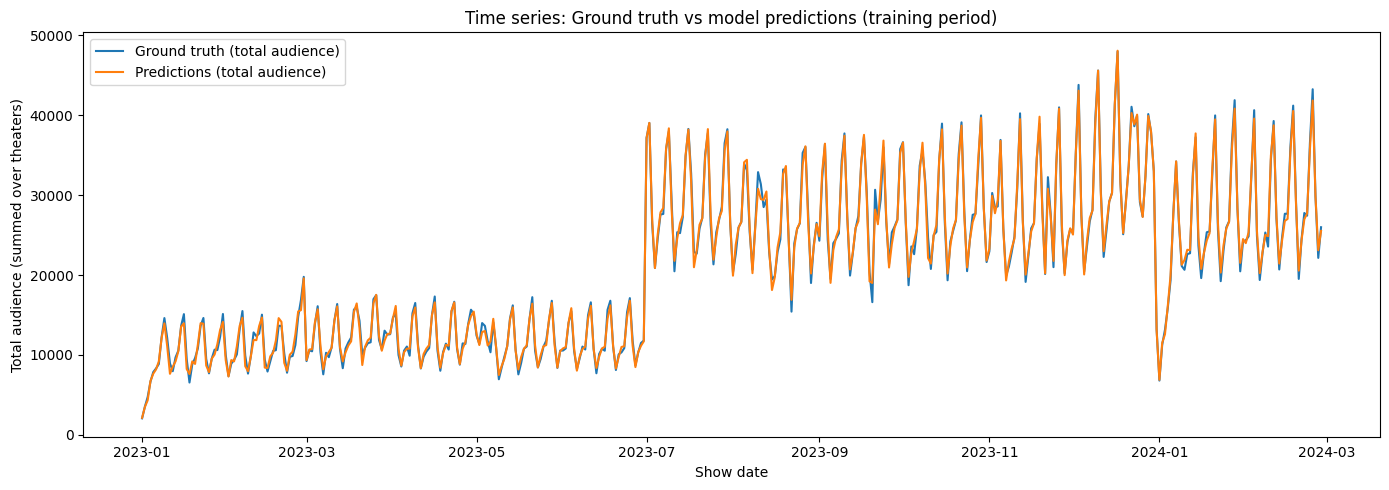

In [238]:

# Time series chart: Ground truth vs predictions (training period)


# Get predictions on the training set
X_train_full = train_df[num_cols + cat_cols]
train_pred = np.clip(final_model.predict(X_train_full), 0, None)

# Building a small DataFrame with true vs predicted
ts_df = train_df[["show_date"]].copy()
ts_df["y_true"] = train_df[TARGET].values
ts_df["y_pred"] = train_pred

# Aggregate per day across all theaters (sum audience)
ts_plot = (
    ts_df.groupby("show_date")[["y_true", "y_pred"]]
         .sum()
         .reset_index()
         .sort_values("show_date")
)

# Plot
plt.figure(figsize=(14, 5))
plt.plot(ts_plot["show_date"], ts_plot["y_true"], label="Ground truth (total audience)")
plt.plot(ts_plot["show_date"], ts_plot["y_pred"], label="Predictions (total audience)")
plt.xlabel("Show date")
plt.ylabel("Total audience (summed over theaters)")
plt.title("Time series: Ground truth vs model predictions (training period)")
plt.legend()
plt.tight_layout()
plt.show()


In [239]:
# clean a bit
del booknow_booking, cinepos_booking, bn_daily, cp_daily, keys, feat
gc.collect()

3450

In [240]:
''''
BASE = "/kaggle/input/Cinema_Audience_Forecasting_challenge"   #(base,variable assigned to prevent repeatability of the code)
fp_booknow_booking   = f"{BASE}/booknow_booking/booknow_booking.csv"
fp_booknow_theaters  = f"{BASE}/booknow_theaters/booknow_theaters.csv"
fp_booknow_visits    = f"{BASE}/booknow_visits/booknow_visits.csv"
fp_cinepos_booking   = f"{BASE}/cinePOS_booking/cinePOS_booking.csv"
fp_relation          = f"{BASE}/movie_theater_id_relation/movie_theater_id_relation.csv"
fp_date_info         = f"{BASE}/date_info/date_info.csv"
fp_sample            = f"{BASE}/sample_submission/sample_submission.csv"  '''

'\'\nBASE = "/kaggle/input/Cinema_Audience_Forecasting_challenge"   #(base,variable assigned to prevent repeatability of the code)\nfp_booknow_booking   = f"{BASE}/booknow_booking/booknow_booking.csv"\nfp_booknow_theaters  = f"{BASE}/booknow_theaters/booknow_theaters.csv"\nfp_booknow_visits    = f"{BASE}/booknow_visits/booknow_visits.csv"\nfp_cinepos_booking   = f"{BASE}/cinePOS_booking/cinePOS_booking.csv"\nfp_relation          = f"{BASE}/movie_theater_id_relation/movie_theater_id_relation.csv"\nfp_date_info         = f"{BASE}/date_info/date_info.csv"\nfp_sample            = f"{BASE}/sample_submission/sample_submission.csv"  '

In [241]:
'''''booknow_booking.shape
ctypes=cinePOS_theaters.dtypes
print((ctypes == "object").sum())
booknow_theaters["theater_type"].mode()
cinePOS_booking['cine_theater_id'].nunique()
book_combined = booknow_theaters.merge(booknow_booking,on="book_theater_id",how="inner")
book_combined.shape
book_combined["theater_area"].nunique()
c_book_theat = cinePOS_booking.merge(cinePOS_theaters,on="cine_theater_id",how="inner")
cine_book_theater_booknow_rel = c_book_theat.merge(movie_theater_id_relation,on="cine_theater_id",how="inner")
cine_book_theater_booknow_rel.isnull().sum()[cine_book_theater_booknow_rel.isnull().sum()>0]
booknow_booking['show_datetime'] = pd.to_datetime(booknow_booking['show_datetime'])
booknow_booking['booking_datetime'] = pd.to_datetime(booknow_booking['booking_datetime'])

start_date = booknow_booking[['show_datetime', 'booking_datetime']].min().min().strftime('%d-%m-%y')
end_date = booknow_booking[['show_datetime', 'booking_datetime']].max().max().strftime('%d-%m-%y')
print(start_date, "to", end_date)
sample_submission['date']=sample_submission['ID'].apply(lambda x: x.split("_")[2])
sample_submission['date'] = pd.to_datetime(sample_submission['date'])
print(sample_submission['date'].min().strftime('%d-%m-%y') ,"to",sample_submission['date'].max().strftime('%d-%m-%y'))
'''

'\'\'booknow_booking.shape\nctypes=cinePOS_theaters.dtypes\nprint((ctypes == "object").sum())\nbooknow_theaters["theater_type"].mode()\ncinePOS_booking[\'cine_theater_id\'].nunique()\nbook_combined = booknow_theaters.merge(booknow_booking,on="book_theater_id",how="inner")\nbook_combined.shape\nbook_combined["theater_area"].nunique()\nc_book_theat = cinePOS_booking.merge(cinePOS_theaters,on="cine_theater_id",how="inner")\ncine_book_theater_booknow_rel = c_book_theat.merge(movie_theater_id_relation,on="cine_theater_id",how="inner")\ncine_book_theater_booknow_rel.isnull().sum()[cine_book_theater_booknow_rel.isnull().sum()>0]\nbooknow_booking[\'show_datetime\'] = pd.to_datetime(booknow_booking[\'show_datetime\'])\nbooknow_booking[\'booking_datetime\'] = pd.to_datetime(booknow_booking[\'booking_datetime\'])\n\nstart_date = booknow_booking[[\'show_datetime\', \'booking_datetime\']].min().min().strftime(\'%d-%m-%y\')\nend_date = booknow_booking[[\'show_datetime\', \'booking_datetime\']].max()

In [242]:
'''import pandas as pd

# Load data
df = pd.read_csv("booknow_visits.csv")

# Create new columns from 'show_date'
df['show_date'] = pd.to_datetime(df['show_date'])
df['day'] = df['show_date'].dt.day
df['month'] = df['show_date'].dt.month
df['year'] = df['show_date'].dt.year
df['dayofyear'] = df['show_date'].dt.dayofyear
df.drop(columns=['show_date'], inplace=True)

# Split into X, y
X = df.drop(columns=['audience_count'])
y = df['audience_count']

# Time-based 80–20 split
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Output shape
print(X_train.shape)
'''

'''import pandas as pd
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVR
from sklearn.metrics import r2_score

# Load data
df = pd.read_csv("booknow_visits.csv")

# Feature engineering: extract date parts
df['show_date'] = pd.to_datetime(df['show_date'])
df['day'] = df['show_date'].dt.day
df['month'] = df['show_date'].dt.month
df['year'] = df['show_date'].dt.year
df['dayofyear'] = df['show_date'].dt.dayofyear
df.drop(columns=['show_date'], inplace=True)

# Split X and y
X = df.drop(columns=['audience_count'])
y = df['audience_count']

# Time-based split (80-20)
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Identify column types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Preprocessing
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# Pipeline with LinearSVR
model = Pipeline([
    ('preprocess', preprocessor),
    ('svr', LinearSVR(random_state=42, max_iter=10000))
])

# Train
model.fit(X_train, y_train)

# Predict & evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print("R2 Score:", round(r2, 3))'''

'''import pandas as pd
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVR
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_absolute_error

# Load data
df = pd.read_csv("booknow_visits.csv")

# Feature engineering
df['show_date'] = pd.to_datetime(df['show_date'])
df['day'] = df['show_date'].dt.day
df['month'] = df['show_date'].dt.month
df['year'] = df['show_date'].dt.year
df['dayofyear'] = df['show_date'].dt.dayofyear
df.drop(columns=['show_date'], inplace=True)

# Split into features & target
X = df.drop(columns=['audience_count'])
y = df['audience_count']

# Time-based split (80-20)
split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Identify numeric & categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Preprocessor
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# Pipeline with preprocessing + SVD + SVR
model = Pipeline([
    ('preprocess', preprocessor),
    ('svd', TruncatedSVD(n_components=4, random_state=42)),
    ('svr', LinearSVR(random_state=42, max_iter=10000))
])

# Train model
model.fit(X_train, y_train)

# Predict on training data
y_train_pred = model.predict(X_train)

# Compute MAE
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_train, y_train_pred)
print("Mean Absolute Error:", round(mae, 3))'''

'import pandas as pd\nfrom sklearn.preprocessing import MinMaxScaler, OneHotEncoder\nfrom sklearn.compose import ColumnTransformer\nfrom sklearn.pipeline import Pipeline\nfrom sklearn.svm import LinearSVR\nfrom sklearn.decomposition import TruncatedSVD\nfrom sklearn.metrics import mean_absolute_error\n\n# Load data\ndf = pd.read_csv("booknow_visits.csv")\n\n# Feature engineering\ndf[\'show_date\'] = pd.to_datetime(df[\'show_date\'])\ndf[\'day\'] = df[\'show_date\'].dt.day\ndf[\'month\'] = df[\'show_date\'].dt.month\ndf[\'year\'] = df[\'show_date\'].dt.year\ndf[\'dayofyear\'] = df[\'show_date\'].dt.dayofyear\ndf.drop(columns=[\'show_date\'], inplace=True)\n\n# Split into features & target\nX = df.drop(columns=[\'audience_count\'])\ny = df[\'audience_count\']\n\n# Time-based split (80-20)\nsplit_index = int(len(df) * 0.8)\nX_train, X_test = X.iloc[:split_index], X.iloc[split_index:]\ny_train, y_test = y.iloc[:split_index], y.iloc[split_index:]\n\n# Identify numeric & categorical columns\